In [43]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import hvplot.pandas
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from pandas.tseries.offsets import DateOffset
import numpy as np
from pathlib import Path
import hvplot.pandas
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from pandas.tseries.offsets import DateOffset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [28]:
import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
sciezka_pliku = "./dane_ekonomiczne.csv"
# Import the OHLCV dataset into a Pandas Dataframe
data = pd.read_csv(
    Path(sciezka_pliku), 
    index_col='Date', 
    infer_datetime_format=True, 
    parse_dates=True
)


C:\Users\jakja\AppData\Local\Temp\ipykernel_58276\4164097040.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv(


In [30]:
# usuwanie zbednych kolumn      
list(data.columns)

cols_to_drop =["High_EURPLN", "Low_EURPLN", "Open_EURPLN", "Volume_EURPLN",
                "High_EURUSD", "Low_EURUSD", "Open_EURUSD", "Volume_EURUSD",
                "High_EURGBP", "Low_EURGBP", "Open_EURGBP", "Volume_EURGBP",
                "Volume_USDPLN", "Italy_GDP", "Germany_GDP", "France_GDP",
                "EA_ECB_IR", "Close_EURGBP", "Poland_GDP", "United Kingdom_GDP"]

data = data.drop(columns=cols_to_drop, errors='ignore')
print("KOLUMNY: \n" + data.columns)
#data = data.drop(columns=["High_EURPLN", "Low_EURPLN", "Open_EURPLN", "Volume_EURPLN",
#                           "High_EURUSD", "Low_EURUSD", "Open_EURUSD", "Volume_EURUSD",
#                           "High_EURGBP", "Low_EURGBP", "Open_EURGBP", "Volume_EURGBP",
#                           "Volume_USDPLN", "Italy_GDP", "Germany_GDP", "France_GDP",
#                            "EA_ECB_IR", "Close_EURGBP", "Poland_GDP", "United Kingdom_GDP",
#                             "", "", "", "",])

Index(['KOLUMNY: \nClose_USDPLN', 'KOLUMNY: \nHigh_USDPLN',
       'KOLUMNY: \nLow_USDPLN', 'KOLUMNY: \nOpen_USDPLN',
       'KOLUMNY: \nClose_EURPLN', 'KOLUMNY: \nClose_EURUSD',
       'KOLUMNY: \nGreat_Britain_CPI', 'KOLUMNY: \nGermany_CPI',
       'KOLUMNY: \nFrance_CPI', 'KOLUMNY: \nItaly_CPI',
       'KOLUMNY: \nUnited_States_CPI', 'KOLUMNY: \nPoland_CPI',
       'KOLUMNY: \nUnited States_GDP', 'KOLUMNY: \nUS_FED_IR',
       'KOLUMNY: \nPL_NBP_IR'],
      dtype='object')


In [31]:
#info o danych
print(data.info)
print(data.describe)
print(data.dtypes)
#sns.heatmap(data, annot=True)
print(data.head())

<bound method DataFrame.info of             Close_USDPLN  High_USDPLN  Low_USDPLN  Open_USDPLN  Close_EURPLN  \
Date                                                                           
2020-01-01      3.805500      3.89020    3.795267     3.805500       4.27080   
2020-01-02      3.793000      3.80540    3.787990     3.793000       4.25540   
2020-01-03      3.794000      3.82550    3.790320     3.794400       4.23840   
2020-01-04      3.794000      3.82550    3.790320     3.794400       4.23840   
2020-01-05      3.794000      3.82550    3.790320     3.794400       4.23840   
...                  ...          ...         ...          ...           ...   
2024-12-27      4.088500      4.10607    4.087050     4.088500       4.26264   
2024-12-28      4.088500      4.10607    4.087050     4.088500       4.26264   
2024-12-29      4.088500      4.10607    4.087050     4.088500       4.26264   
2024-12-30      4.092367      4.11964    4.073600     4.092367       4.26793   
2024-12-

In [32]:
print(data.shape)
print(data.columns)
print(data.isna().sum())

(1827, 15)
Index(['Close_USDPLN', 'High_USDPLN', 'Low_USDPLN', 'Open_USDPLN',
       'Close_EURPLN', 'Close_EURUSD', 'Great_Britain_CPI', 'Germany_CPI',
       'France_CPI', 'Italy_CPI', 'United_States_CPI', 'Poland_CPI',
       'United States_GDP', 'US_FED_IR', 'PL_NBP_IR'],
      dtype='object')
Close_USDPLN         0
High_USDPLN          0
Low_USDPLN           0
Open_USDPLN          0
Close_EURPLN         0
Close_EURUSD         0
Great_Britain_CPI    0
Germany_CPI          0
France_CPI           0
Italy_CPI            0
United_States_CPI    0
Poland_CPI           0
United States_GDP    0
US_FED_IR            0
PL_NBP_IR            0
dtype: int64


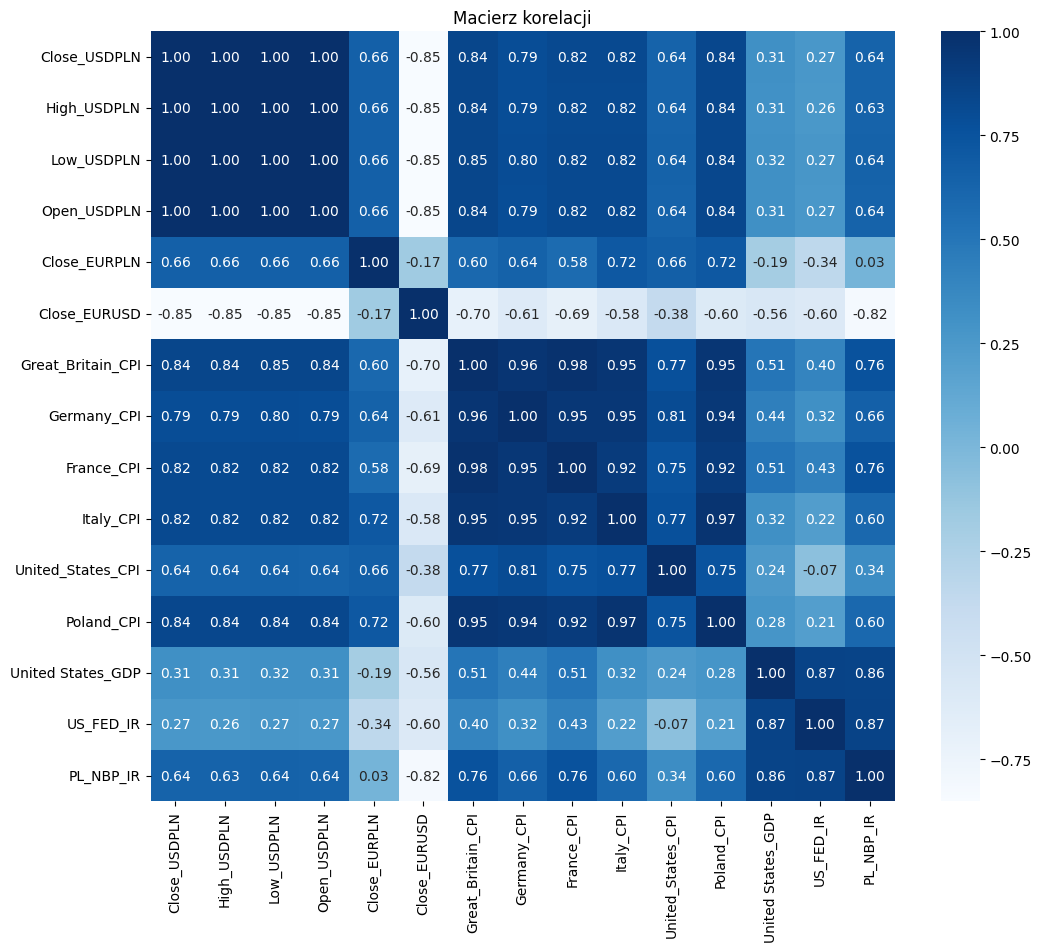

In [33]:


corr = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()


In [48]:
# SMA
signals_df = data.loc[:, ["Close_USDPLN"]]
signals_df["Actual Returns USDPLN"] = signals_df["Close_USDPLN"].pct_change()
signals_df = signals_df.dropna()

# Set the short window and long window
short_window = 15
long_window = 60

# Generate the fast and slow simple moving averages (4 and 100 days, respectively)
signals_df['SMA_Fast'] = signals_df['Close_USDPLN'].rolling(window=short_window).mean()
signals_df['SMA_Slow'] = signals_df['Close_USDPLN'].rolling(window=long_window).mean()

signals_df = signals_df.dropna()

# Review the DataFrame
display(signals_df.head())
display(signals_df.tail())

,Close_USDPLN,Actual Returns USDPLN,SMA_Fast,SMA_Slow
Date,,,,
2020-03-01,3.93008,0.000000,3.946741,3.869959
2020-03-02,3.92190,-0.002081,3.947208,3.872107
2020-03-03,3.87420,-0.012162,3.944417,3.873444
2020-03-04,3.85500,-0.004956,3.939351,3.874460
2020-03-05,3.85614,0.000296,3.932936,3.875496


,Close_USDPLN,Actual Returns USDPLN,SMA_Fast,SMA_Slow
Date,,,,
2024-12-27,4.088500,0.000020,4.084617,4.066058
2024-12-28,4.088500,0.000000,4.085343,4.067203
2024-12-29,4.088500,0.000000,4.086069,4.068527
2024-12-30,4.092367,0.000946,4.087052,4.069939
2024-12-31,4.107070,0.003593,4.090551,4.071758


,Close_USDPLN,Actual Returns USDPLN,SMA_Fast,SMA_Slow,Signal,Strategy Returns
Date,,,,,,
2020-03-01,3.93008,0.000000,3.946741,3.869959,1.0,NaN
2020-03-02,3.92190,-0.002081,3.947208,3.872107,-1.0,-0.002081
2020-03-03,3.87420,-0.012162,3.944417,3.873444,-1.0,0.012162
2020-03-04,3.85500,-0.004956,3.939351,3.874460,-1.0,0.004956
2020-03-05,3.85614,0.000296,3.932936,3.875496,1.0,-0.000296


,Close_USDPLN,Actual Returns USDPLN,SMA_Fast,SMA_Slow,Signal,Strategy Returns
Date,,,,,,
2024-12-27,4.088500,0.000020,4.084617,4.066058,1.0,0.000020
2024-12-28,4.088500,0.000000,4.085343,4.067203,1.0,0.000000
2024-12-29,4.088500,0.000000,4.086069,4.068527,1.0,0.000000
2024-12-30,4.092367,0.000946,4.087052,4.069939,1.0,0.000946
2024-12-31,4.107070,0.003593,4.090551,4.071758,1.0,0.003593


<Axes: xlabel='Date'>

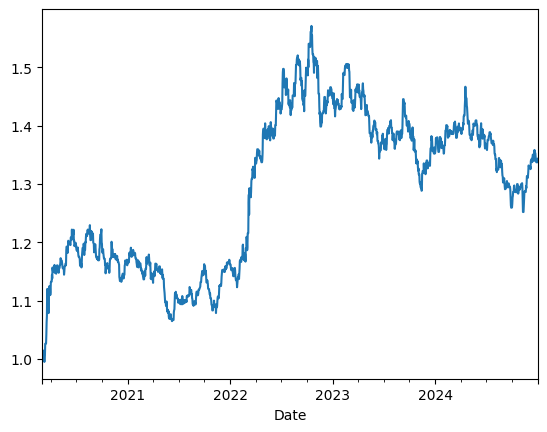

In [49]:
# Initialize the new Signal column
signals_df['Signal'] = 0.0

# When Actual Returns are greater than or equal to 0, generate signal to buy stock long
signals_df.loc[(signals_df['Actual Returns USDPLN'] >= 0), 'Signal'] = 1

# When Actual Returns are less than 0, generate signal to sell stock short
signals_df.loc[(signals_df['Actual Returns USDPLN'] < 0), 'Signal'] = -1

# Calculate the strategy returns and add them to the signals_df DataFrame
signals_df['Strategy Returns'] = signals_df['Actual Returns USDPLN'] * signals_df['Signal'].shift()

display(signals_df.head())
display(signals_df.tail())

# Plot Strategy Returns to examine performance
(1 + signals_df['Strategy Returns']).cumprod().plot()


In [64]:
# Assign a copy of the sma_fast and sma_slow columns to a features DataFrame called X
X = signals_df[['SMA_Fast', 'SMA_Slow']].shift().dropna()

# Review the DataFrame
X.head()

# Create the target set selecting the Signal column and assiging it to y
y = signals_df['Signal']

# Review the value counts
y.value_counts()

# # Select the start of the training period
# training_begin = X.index.min()

# # Display the training begin date
# print(training_begin)

# # Select the ending period for the training data with an offset of 3 months
# training_end = X.index.min() + DateOffset(months=1)

# # Display the training end date
# print(training_end)

# # Generate the X_train and y_train DataFrames
# X_train = X.loc[training_begin:training_end]
# y_train = y.loc[training_begin:training_end]

# # Review the X_train DataFrame
# display(X_train.head())

# # Generate the X_test and y_test DataFrames
# X_test = X.loc[training_end+DateOffset(hours=1):]
# y_test = y.loc[training_end+DateOffset(hours=1):]



split = int(len(X) * 0.7)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]



# Review the X_test DataFrame
display(X_test.head())



print(y_train.value_counts())
print()
print(y_test.value_counts())

,SMA_Fast,SMA_Slow
Date,,
2023-07-21,4.019704,4.101332
2023-07-22,4.012167,4.098013
2023-07-23,4.004350,4.095282
2023-07-24,3.996534,4.092486
2023-07-25,3.989621,4.089523


Signal
 1.0    786
-1.0    450
Name: count, dtype: int64

Signal
 1.0    335
-1.0    196
Name: count, dtype: int64


In [51]:
# Scale the features DataFrames

# Create a StandardScaler instance
scaler = StandardScaler()

# Apply the scaler model to fit the X-train data
X_scaler = scaler.fit(X_train)

# Transform the X_train and X_test DataFrames using the X_scaler
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [52]:
# From SVM, instantiate SVC classifier model instance
svm_model = svm.SVC()
 
# Fit the model to the data using the training data
svm_model = svm_model.fit(X_train_scaled, y_train)
 
# Use the testing data to make the model predictions
svm_pred = svm_model.predict(X_test_scaled)

# Review the model's predicted values
svm_pred[:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [53]:
# Use a classification report to evaluate the model using the predictions and testing data
svm_testing_report = classification_report(y_test, svm_pred)

# Print the classification report
print(svm_testing_report)

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)

print("Confusion Matrix:")
print(cm)

# TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

              precision    recall  f1-score   support

        -1.0       0.25      0.00      0.01       636
         1.0       0.63      0.99      0.77      1098

    accuracy                           0.63      1734
   macro avg       0.44      0.50      0.39      1734
weighted avg       0.49      0.63      0.49      1734

Confusion Matrix:
[[   3  633]
 [   9 1089]]
TN = 3
FP = 633
FN = 9
TP = 1089


In [59]:
# Create a new empty predictions DataFrame:

# Create a predictions DataFrame
predictions_df = pd.DataFrame(index = X_test.index)

# Add the SVM model predictions to the DataFrame
predictions_df['Predicted'] = svm_pred

# Add the actual returns to the DataFrame
predictions_df['Actual Returns USDPLN'] = signals_df['Actual Returns USDPLN']

# Add the strategy returns to the DataFrame
predictions_df['Strategy Returns'] = predictions_df['Actual Returns USDPLN'] * predictions_df['Predicted']

# Review the DataFrame
display(predictions_df.head())
display(predictions_df.tail())

,Predicted,Actual Returns USDPLN,Strategy Returns
Date,,,
2020-04-03,1.0,0.001453,0.001453
2020-04-04,1.0,0.000000,0.000000
2020-04-05,1.0,0.000000,0.000000
2020-04-06,1.0,0.010350,0.010350
2020-04-07,1.0,-0.005440,-0.005440


,Predicted,Actual Returns USDPLN,Strategy Returns
Date,,,
2024-12-27,1.0,0.000020,0.000020
2024-12-28,1.0,0.000000,0.000000
2024-12-29,1.0,0.000000,0.000000
2024-12-30,1.0,0.000946,0.000946
2024-12-31,1.0,0.003593,0.003593


<Axes: xlabel='Date'>

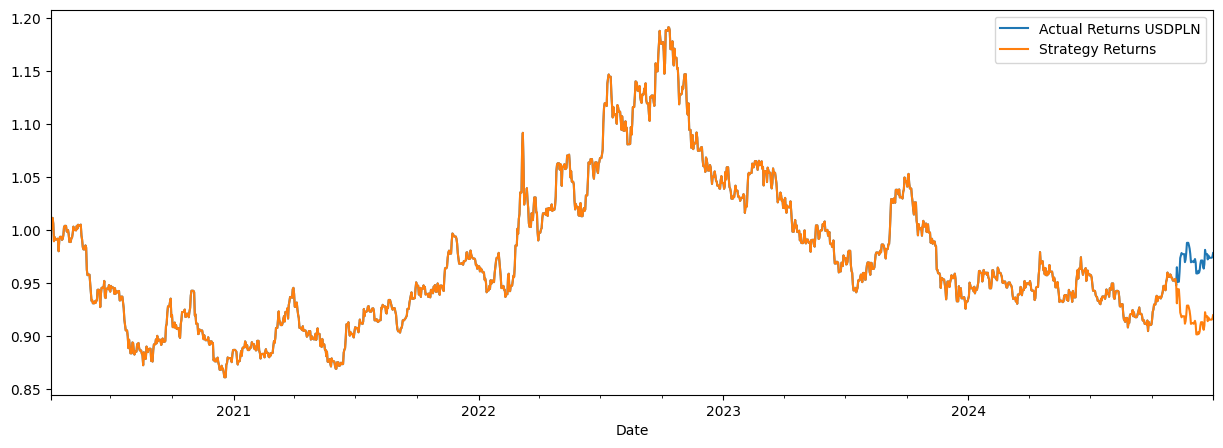

In [61]:
# Plot the actual returns versus the strategy returns
(1 + predictions_df[['Actual Returns USDPLN', 'Strategy Returns']]).cumprod().plot(figsize = (15,5))